<a href="https://colab.research.google.com/github/VinniciusHeinz/ML-CHATBOT-UNIAO/blob/aula_4/Damos_lhe_as_boas_vindas_ao_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Damos-lhe as boas-vindas ao Colab!

--- Demonstração do Algoritmo ---
Valores Reais (y):      [10. 20. 30.]
Valores Previstos (ŷ):  [12. 18. 40.]
---------------------------------
MAE calculado:  4.67
RMSE calculado: 6.00


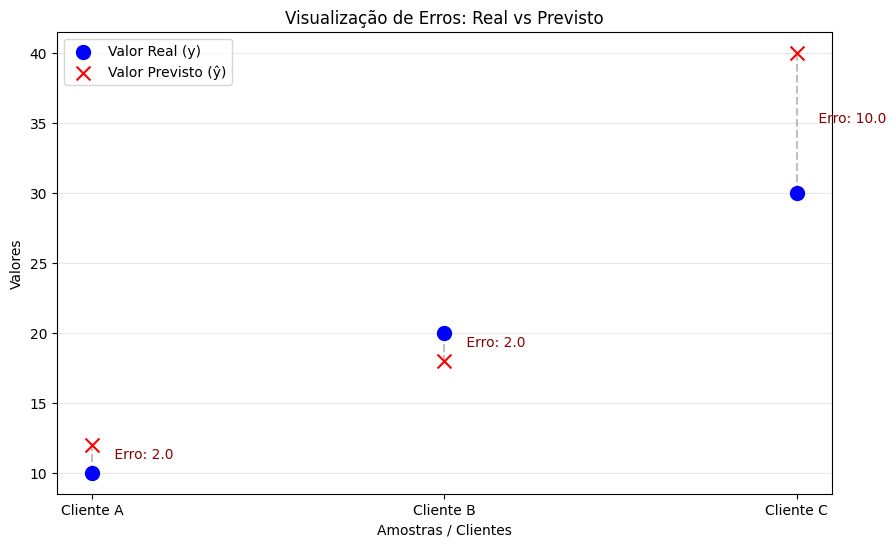

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. DEFINIÇÃO DOS DADOS (O que aconteceu na realidade vs O que o modelo previu)
# y_real representa os valores verdadeiros (Ground Truth)
y_real = np.array([10.0, 20.0, 30.0])

# y_hat representa o valor PREVISTO pelo modelo (ŷ)
y_hat = np.array([12.0, 18.0, 40.0])

# 2. CÁLCULO DOS RESÍDUOS (A diferença individual)
# Subtraímos o valor real do previsto para encontrar o erro de cada ponto
residuos = y_real - y_hat

# 3. ALGORITMO DO MAE (Mean Absolute Error)
# Passo A: Transformamos todos os erros em valores positivos (absolutos)
erros_absolutos = np.abs(residuos)
# Passo B: Calculamos a média desses valores positivos
mae = np.mean(erros_absolutos)

# 4. ALGORITMO DO RMSE (Root Mean Squared Error)
# Passo A: Elevamos os erros ao quadrado (isso elimina o sinal e penaliza erros grandes)
erros_quadraticos = residuos ** 2
# Passo B: Calculamos a média dos erros quadráticos (MSE)
mse = np.mean(erros_quadraticos)
# Passo C: Extraímos a raiz quadrada para voltar à unidade de medida original
rmse = np.sqrt(mse)

# 5. EXIBIÇÃO DOS RESULTADOS NO TERMINAL
print("--- Demonstração do Algoritmo ---")
print(f"Valores Reais (y):      {y_real}")
print(f"Valores Previstos (ŷ):  {y_hat}")
print("-" * 33)
print(f"MAE calculado:  {mae:.2f}")
print(f"RMSE calculado: {rmse:.2f}")

# 6. VISUALIZAÇÃO GRÁFICA (A distância como erro)
plt.figure(figsize=(10, 6))

# Plota os valores reais como pontos azuis
plt.scatter(range(len(y_real)), y_real, color='blue', label='Valor Real (y)', s=100, zorder=3)
# Plota as previsões como "X" vermelhos
plt.scatter(range(len(y_hat)), y_hat, color='red', marker='x', label='Valor Previsto (ŷ)', s=100, zorder=3)

# Desenha linhas verticais para representar o erro (distância)
for i in range(len(y_real)):
    plt.vlines(i, y_real[i], y_hat[i], colors='gray', linestyles='dashed', alpha=0.5)
    plt.text(i + 0.05, (y_real[i] + y_hat[i])/2, f' Erro: {abs(residuos[i])}', color='darkred')

# Configurações do Gráfico
plt.title('Visualização de Erros: Real vs Previsto')
plt.xlabel('Amostras / Clientes')
plt.ylabel('Valores')
plt.xticks(range(len(y_real)), ['Cliente A', 'Cliente B', 'Cliente C'])
plt.legend()
plt.grid(True, axis='y', alpha=0.3)

# Exibe o gráfico
plt.show()

# OBSERVAÇÃO TÉCNICA:
# Note no gráfico que a distância do 'Cliente C' é a maior.
# No RMSE, essa distância de 10 unidades vira 100 no cálculo, elevando a média final.


In [3]:
import pandas as pd  # Importa a biblioteca para manipulação de tabelas
import numpy as np   # Importa a biblioteca para cálculos matemáticos e aleatórios

np.random.seed(42)

# Criando dados simulados de um Chatbot: Custo Real vs Custo Previsto pelo modelo
n_amostras = 100  # Define que teremos 100 linhas de dados
custo_real = np.random.uniform(10.0, 50.0, n_amostras)  # Gera custos reais entre 10 e 50 reais

# Simula a previsão do modelo com um pequeno erro (ruído)
# O erro médio aqui é propositalmente de aproximadamente 2 unidades
previsao_modelo = custo_real + np.random.normal(0, 2, n_amostras)

# Adiciona 3 "erros grosseiros" (outliers) para testar o peso no RMSE
previsao_modelo[0] += 50  # Erro de 50 reais a mais na primeira linha
previsao_modelo[10] -= 40 # Erro de 40 reais a menos na linha 10
previsao_modelo[50] += 60 # Erro de 60 reais a mais na linha 50

# Monta o DataFrame (tabela)
df_metricas = pd.DataFrame({
    'custo_real': custo_real,
    'previsao_modelo': previsao_modelo
})

# Salva o arquivo CSV para ser usado nos exercícios
df_metricas.to_csv('dados_metricas_aula04.csv', index=False)
print("✅ Arquivo 'dados_metricas_aula04.csv' gerado com sucesso!")

✅ Arquivo 'dados_metricas_aula04.csv' gerado com sucesso!


In [4]:
import pandas as pd  # Importa biblioteca para ler dados
import numpy as np   # Importa biblioteca para operações matemáticas
from sklearn.metrics import mean_absolute_error  # Importa a função de métrica

# Lendo os dados gerados anteriormente
df = pd.read_csv('dados_metricas_aula04.csv')

# --- EXERCÍCIO: CÁLCULO E INTERPRETAÇÃO DO MAE ---
# O MAE foca no erro médio "bruto", sem dar peso extra a erros grandes.
mae = mean_absolute_error(df['custo_real'], df['previsao_modelo'])  # Calcula a média das distâncias absolutas
print(f"1. MAE (Erro Médio Absoluto): R$ {mae:.2f}")  # Exibe o erro médio em formato de moeda
# Explicação: Este valor indica que, na média, o bot erra o custo por esse valor fixo.


1. MAE (Erro Médio Absoluto): R$ 2.87


In [5]:
import pandas as pd  # Importa biblioteca para ler dados
import numpy as np   # Importa biblioteca para operações matemáticas
from sklearn.metrics import mean_squared_error  # Importa a função de métrica

# Lendo os dados gerados anteriormente
df = pd.read_csv('dados_metricas_aula04.csv')

# --- EXERCÍCIO: CÁLCULO E INTERPRETAÇÃO DO RMSE ---
# O RMSE penaliza erros grandes (outliers) elevando-os ao quadrado antes da média.
mse = mean_squared_error(df['custo_real'], df['previsao_modelo'])  # Calcula a média dos erros ao quadrado
rmse = np.sqrt(mse)  # Extrai a raiz quadrada do MSE para voltar à unidade original (Reais)
print(f"2. RMSE (Raiz do Erro Quadrático Médio): R$ {rmse:.2f}")  # Exibe o resultado
# Explicação: Note que o RMSE é maior que o MAE porque "sentiu" os 3 erros grandes.

2. RMSE (Raiz do Erro Quadrático Médio): R$ 8.75


In [6]:
import pandas as pd  # Importa pandas para criar o arquivo
import numpy as np   # Importa numpy para gerar números aleatórios

# Simulando o comprimento das mensagens (número de caracteres) que o bot recebeu em um dia
# Queremos dados com alguns valores repetidos para testar a Moda e Mediana
comprimentos = [10, 15, 15, 20, 25, 30, 30, 30, 45, 50, 60, 100, 150, 200, 30, 15]

# Adicionando mais dados aleatórios para aumentar a base
np.random.seed(10)
dados_extras = np.random.randint(10, 100, 50).tolist()
comprimento_total = comprimentos + dados_extras

# Criando o DataFrame
df_estatistica = pd.DataFrame({'tamanho_mensagem': comprimento_total})

# Salvando o CSV
df_estatistica.to_csv('dados_estatistica_aula04.csv', index=False)
print(" Arquivo 'dados_estatistica_aula04.csv' gerado com sucesso!")

 Arquivo 'dados_estatistica_aula04.csv' gerado com sucesso!


In [7]:
import pandas as pd
import numpy as np

# Lendo os dados de tamanho de mensagem
df = pd.read_csv('dados_estatistica_aula04.csv')

# --- MÉDIA (MEAN) ---
media = df['tamanho_mensagem'].mean()  # Soma todos os tamanhos e divide pela quantidade de mensagens
print(f"3. Média de caracteres: {media:.2f}")  # Exibe o valor médio das mensagens

# --- MEDIANA (MEDIAN) ---
mediana = df['tamanho_mensagem'].median()  # Ordena os dados e pega o valor que está exatamente no meio
print(f"4. Mediana de caracteres: {mediana:.2f}")  # Exibe o valor central
# Objetivo: Ver o centro sem a interferência de valores extremos (mensagens gigantes).

# --- MODA (MODE) ---
moda = df['tamanho_mensagem'].mode()[0]  # Identifica qual o valor que mais se repete na lista
print(f"5. Moda de caracteres: {moda}")  # Exibe o tamanho de mensagem mais frequente
# Objetivo: Identificar o padrão de comportamento mais comum dos usuários.

# --- DESVIO PADRÃO (STANDARD DEVIATION) ---
desvio = df['tamanho_mensagem'].std()  # Calcula o quanto os dados estão afastados da média
print(f"6. Desvio Padrão: {desvio:.2f}")  # Exibe a dispersão dos dados
# Objetivo: Saber se as mensagens têm tamanhos parecidos ou se variam drasticamente.

3. Média de caracteres: 52.70
4. Mediana de caracteres: 40.50
5. Moda de caracteres: 30
6. Desvio Padrão: 35.31
